<a href="https://colab.research.google.com/github/Silvy66/World_Suicide_rates/blob/main/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EDA - Dataset de Tasas de Suicidio

## Contexto del problema

El modelo desarrollado busca clasificar el nivel de tasa de suicidio de un país en diferentes categorías (por ejemplo: bajo, medio, alto), a partir de variables como año, país y otras características del dataset.

Esto implica que no estamos prediciendo un valor exacto, sino clasificando el nivel de riesgo.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Estilo global de graficas
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

# Cargar dataset
df = pd.read_csv('Suicide.csv')

# Ver columnas
print(df.columns)
print(df.head())

Index(['iso_code', 'country', 'year', 'sex', 'age_group', 'suicide_rate'], dtype='str')
  iso_code      country  year     sex age_group  suicide_rate
0      AFG  Afghanistan  2000    male       ALL      5.793457
1      AFG  Afghanistan  2000    both       ALL      4.356148
2      AFG  Afghanistan  2000  female       ALL      2.910393
3      AFG  Afghanistan  2001    male       ALL      5.831328
4      AFG  Afghanistan  2001    both       ALL      4.383031


------------------------------------------------------------------------------------------
#**Identificación de Valores Faltantes**

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18315 entries, 0 to 18314
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   iso_code      18315 non-null  object 
 1   country       18315 non-null  object 
 2   year          18315 non-null  int64  
 3   sex           18315 non-null  object 
 4   age_group     18315 non-null  object 
 5   suicide_rate  18315 non-null  float64
dtypes: float64(1), int64(1), object(4)
memory usage: 858.6+ KB


In [31]:

# Identificación de valores faltantes

missing_abs = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)

tabla_faltantes = pd.DataFrame({
    'valores_faltantes': missing_abs,
    'porcentaje_%': missing_pct
}).sort_values(by='valores_faltantes', ascending=False)

print("Resumen de valores faltantes por variable:")
display(tabla_faltantes)

print("\nColumnas con valores faltantes:")
display(tabla_faltantes[tabla_faltantes['valores_faltantes'] > 0])

Resumen de valores faltantes por variable:


,valores_faltantes,porcentaje_%
iso_code,0,0.0
country,0,0.0
year,0,0.0
sex,0,0.0
age_group,0,0.0
suicide_rate,0,0.0



Columnas con valores faltantes:


,valores_faltantes,porcentaje_%


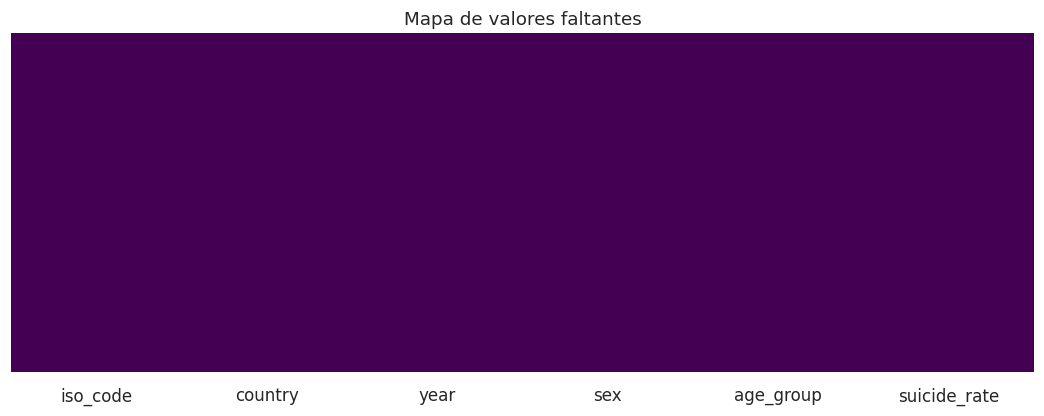

In [16]:
plt.figure(figsize=(12, 4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Mapa de valores faltantes')
plt.show()

In [ ]:

# Búsqueda de valores faltantes implícitos

valores_sospechosos = ["Unknown", "NA", "N/A", "null", "", "None"]

for col in df.columns:
    conteo = df[col].isin(valores_sospechosos).sum()
    print(f"{col}: {conteo} posibles valores faltantes implícitos")

iso_code: 0 posibles valores faltantes implícitos
country: 0 posibles valores faltantes implícitos
year: 0 posibles valores faltantes implícitos
sex: 0 posibles valores faltantes implícitos
age_group: 0 posibles valores faltantes implícitos
suicide_rate: 0 posibles valores faltantes implícitos


In [33]:
##DEtección de rarezas
for col in df.columns:
    print(f"\nValores únicos en {col}:")
    print(df[col].unique()[:10])


Valores únicos en iso_code:
['AFG' 'AGO' 'ALB' 'ARE' 'ARG' 'ARM' 'ATG' 'AUS' 'AUT' 'AZE']

Valores únicos en country:
['Afghanistan' 'Angola' 'Albania' 'United Arab Emirates' 'Argentina'
 'Armenia' 'Antigua and Barbuda' 'Australia' 'Austria' 'Azerbaijan']

Valores únicos en year:
[2000 2001 2002 2003 2004 2005 2006 2007 2008 2009]

Valores únicos en sex:
['male' 'both' 'female']

Valores únicos en age_group:
['ALL' '20_29' '30_49' '15_19' '70_PLUS' '30_39' '15_29' '60_69' '50_69'
 '50_59']

Valores únicos en suicide_rate:
[5.79345742 4.35614796 2.9103934  5.8313281  4.38303062 2.92394385
 2.71426647 5.78192571 4.25500445 4.23828803]


### Conclusión - Valores faltantes

El análisis de valores faltantes evidenció que el dataset no presenta valores nulos explícitos en ninguna de sus variables, lo que indica una buena calidad estructural inicial de los datos.

El mapa de calor confirma la ausencia total de valores faltantes, ya que no se observan espacios vacíos en ninguna columna.

Adicionalmente, se realizó una búsqueda de valores faltantes implícitos (como "NA", "Unknown","None" o cadenas vacías), sin encontrarse registros que representen este tipo de inconsistencias.
Tambien se realizo una busqueda de rarezas, para encontrar errores como (
"N/a", "missing", "?", "--","0"), encontrado como resultado valoresunicos para cada variable.

Aunque no fue necesario aplicar técnicas de tratamiento en este caso, se consideran como estrategias generales:
- Eliminación de registros cuando la variable objetivo esté ausente.
- Imputación con mediana para variables numéricas.
- Uso de categorías como "Desconocido" en variables categóricas.

Esto garantiza que el análisis es robusto ante posibles escenarios con datos incompletos.

In [19]:
df.tail()

,iso_code,country,year,sex,age_group,suicide_rate
18310,ZWE,Zimbabwe,2021,male,20_29,24.592566
18311,ZWE,Zimbabwe,2021,male,15_29,22.297359
18312,ZWE,Zimbabwe,2021,female,15_19,9.802394
18313,ZWE,Zimbabwe,2021,both,50_59,49.098438
18314,ZWE,Zimbabwe,2021,male,10_19,9.177570


In [64]:
# Detalle de Tabla
print('Filas: ', df.shape[0])
print('Columnas: ',df.shape[1])

Filas:  18315
Columnas:  7


----------------------------------------------------------------------------------------------
#**Detección de Valores Atípicos**

In [34]:

# Identificar las Variables numéricas

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Variables numéricas:", numeric_cols)

Variables numéricas: ['year', 'suicide_rate']


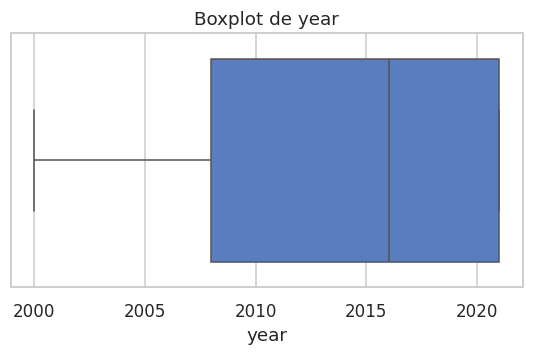

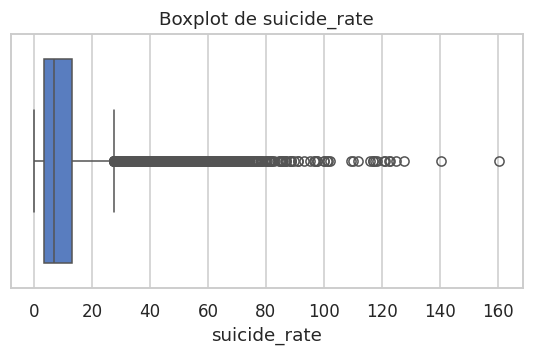

In [35]:

# Boxplots

for col in numeric_cols:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot de {col}')
    plt.show()

La variable `suicide_rate` presenta una distribución altamente asimétrica hacia la derecha, con una gran concentración de valores bajos y una cola larga de valores altos.

Se identifican múltiples valores atípicos según el boxplot. Sin embargo, estos no necesariamente representan errores, sino posibles situaciones reales de ciertos países o años con tasas elevadas.

Por lo tanto, no se recomienda su eliminación directa, sino su análisis o transformación en etapas posteriores.

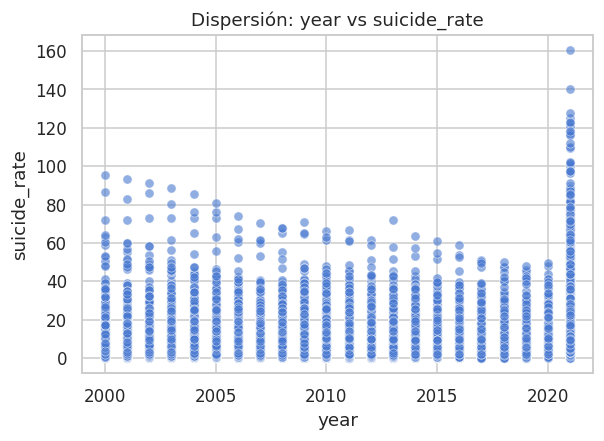

In [36]:

# Diagrama de dispersión


if 'year' in df.columns and 'suicide_rate' in df.columns:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(data=df, x='year', y='suicide_rate', alpha=0.6)
    plt.title('Dispersión: year vs suicide_rate')
    plt.show()

In [37]:

# Detección de outliers con IQR


resumen_iqr = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    outliers = df[(df[col] < limite_inferior) | (df[col] > limite_superior)]

    resumen_iqr.append({
        'variable': col,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'lim_inf': limite_inferior,
        'lim_sup': limite_superior,
        'n_outliers': len(outliers),
        'porcentaje': round(len(outliers) / len(df) * 100, 2)
    })

resumen_iqr_df = pd.DataFrame(resumen_iqr)
display(resumen_iqr_df)

,variable,Q1,Q3,IQR,lim_inf,lim_sup,n_outliers,porcentaje
0,year,2008.000000,2021.000000,13.000000,1988.500000,2040.500000,0,0.00
1,suicide_rate,3.432448,13.080171,9.647723,-11.039136,27.551755,1286,7.02


In [38]:

# Detección de outliers con z-score

from scipy import stats
import numpy as np

resumen_z = []

for col in numeric_cols:
    if df[col].std() != 0:
        z_scores = np.abs(stats.zscore(df[col]))
        outliers_z = (z_scores > 3).sum()
    else:
        outliers_z = 0

    resumen_z.append({
        'variable': col,
        'outliers_zscore': int(outliers_z),
        'porcentaje': round(outliers_z / len(df) * 100, 2)
    })

resumen_z_df = pd.DataFrame(resumen_z)
display(resumen_z_df)

,variable,outliers_zscore,porcentaje
0,year,0,0.00
1,suicide_rate,378,2.06


### Conclusión - Valores atípicos

Se identificaron posibles valores atípicos utilizando métodos gráficos (boxplots y diagramas de dispersión) y métodos estadísticos (IQR y z-score).

Los resultados muestran la presencia de valores extremos, especialmente en la variable `suicide_rate`.

Sin embargo, dado que el dataset corresponde a datos reales de países y años, estos valores no necesariamente representan errores, sino posibles situaciones reales de alta o baja tasa de suicidio.

Por lo tanto, no se recomienda eliminar automáticamente los outliers. En su lugar:
- Se pueden conservar para análisis descriptivo.
- Se podrían aplicar transformaciones (como logaritmo) si se desea modelar.
- Se podrían usar técnicas robustas si se construyen modelos predictivos.

Esto permite preservar la información relevante sin distorsionar la interpretación del fenómeno.

-------------------------------------------------------------------------------------------------
# **Análisis de Distribuciones**

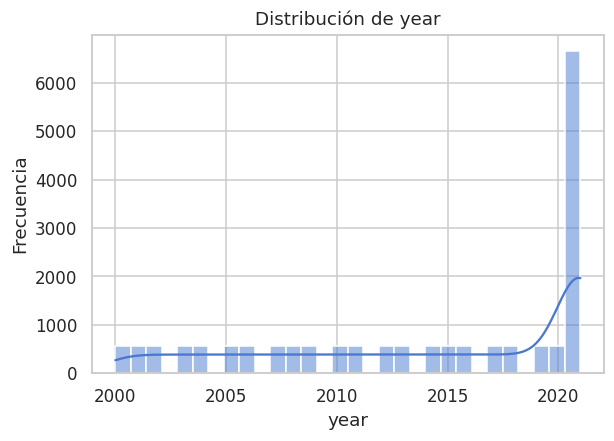

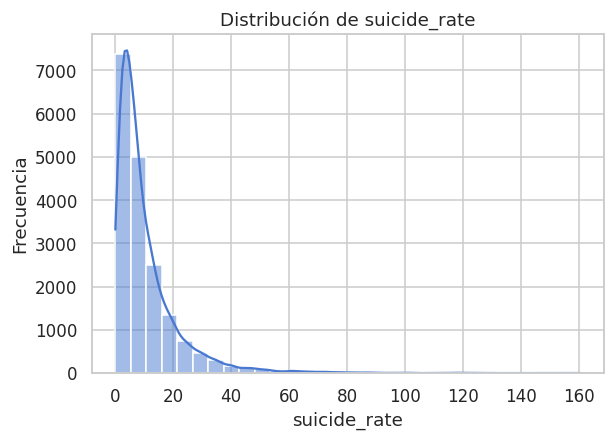

In [39]:

# Histogramas y densidad


for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribución de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.show()

In [40]:

# Estadísticos de distribución


resumen_dist = []

for col in numeric_cols:
    resumen_dist.append({
        'variable': col,
        'media': df[col].mean(),
        'mediana': df[col].median(),
        'desv_std': df[col].std(),
        'skewness': round(df[col].skew(), 4),
        'kurtosis': round(df[col].kurt(), 4)
    })

resumen_dist_df = pd.DataFrame(resumen_dist)
display(resumen_dist_df)

,variable,media,mediana,desv_std,skewness,kurtosis
0,year,2014.000000,2016.000000,7.164924,-0.5330,-1.1741
1,suicide_rate,10.407798,6.837156,11.525414,3.2143,17.0842


Skewness original: 3.2143
Skewness log1p: 0.0667


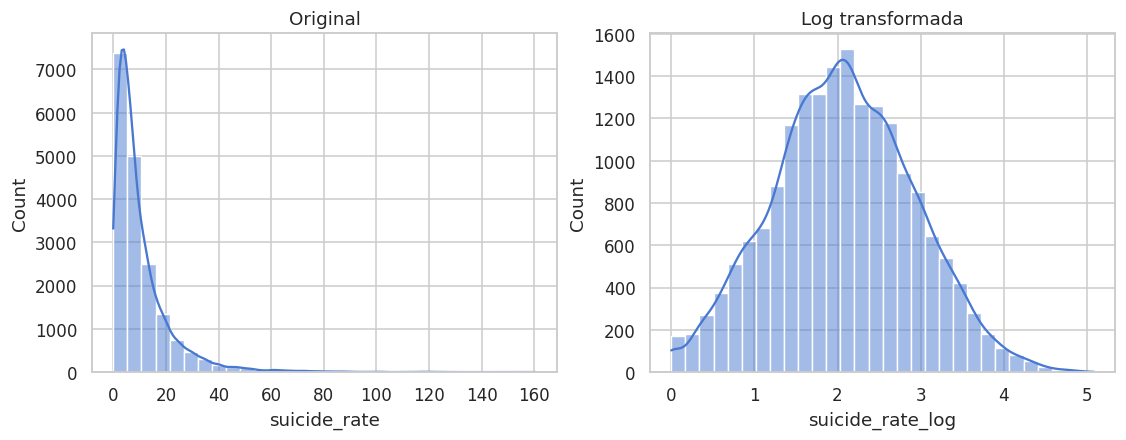

In [41]:

# Transformación logarítmica


df_dist = df.copy()

if 'suicide_rate' in df_dist.columns:
    df_dist['suicide_rate_log'] = np.log1p(df_dist['suicide_rate'])

    print("Skewness original:", round(df['suicide_rate'].skew(), 4))
    print("Skewness log1p:", round(df_dist['suicide_rate_log'].skew(), 4))

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    sns.histplot(df['suicide_rate'], kde=True, bins=30)
    plt.title('Original')

    plt.subplot(1, 2, 2)
    sns.histplot(df_dist['suicide_rate_log'], kde=True, bins=30)
    plt.title('Log transformada')

    plt.show()

In [42]:

# Estandarización

from sklearn.preprocessing import StandardScaler

df_scaled = df.copy()

scaler = StandardScaler()
df_scaled[numeric_cols] = scaler.fit_transform(df_scaled[numeric_cols])

print(df_scaled[numeric_cols].head())

       year  suicide_rate
0 -1.954017     -0.400373
1 -1.954017     -0.525084
2 -1.954017     -0.650528
3 -1.814444     -0.397087
4 -1.814444     -0.522752


### Conclusión - Análisis de distribuciones

Se analizaron las variables numéricas mediante histogramas y curvas de densidad, observándose la forma de sus distribuciones.

La variable `suicide_rate` presenta asimetría positiva (sesgo hacia la derecha), evidenciada por la diferencia entre media y mediana y confirmada por el coeficiente de skewness.

Esto indica que la distribución no es normal y está influenciada por valores extremos (outliers), lo cual es consistente con el análisis previo.

Se aplicó una transformación logarítmica (log1p), la cual reduce la asimetría y permite una distribución más equilibrada.

Adicionalmente, se realizó estandarización como paso opcional para futuros modelos, aunque no es estrictamente necesaria para el análisis descriptivo.

En conclusión, los datos no siguen una distribución normal y requieren transformaciones si se desea aplicar modelos estadísticos sensibles a la normalidad.

------------------------------------------------------------------------------------------
#**Trasnformación y Clasificación**

In [43]:
# Clasificacion en 3 clases (Bajo, medio y alto)
# Asegurar que suicide_rate sea numerico
df['suicide_rate'] = pd.to_numeric(df['suicide_rate'], errors='coerce')

# No se eliminan valores nulos ya que no se detectaron en el análisis previo
#df = df.dropna(subset=['suicide_rate'])

# Calcular percentiles
q1 = df['suicide_rate'].quantile(0.33)
q2 = df['suicide_rate'].quantile(0.66)

# Crear la clasificacion (0 = bajo, 1 = medio, 2 = alto)
df['level'] = df['suicide_rate'].apply(
    lambda x: 0 if x <= q1 else (1 if x <= q2 else 2)
)

# Ver resultados
print("Distribucion de clases:")
print(df['level'].value_counts())

print("\nEjemplo:")
print(df[['suicide_rate', 'level']].head(10))

Distribucion de clases:
level
2    6227
1    6044
0    6044
Name: count, dtype: int64

Ejemplo:
   suicide_rate  level
0      5.793457      1
1      4.356148      0
2      2.910393      0
3      5.831328      1
4      4.383031      1
5      2.923944      0
6      2.714266      0
7      5.781926      1
8      4.255004      0
9      4.238288      0


In [44]:
print("minimo: ", df['suicide_rate'].min())
print("maximo: ", df['suicide_rate'].max())

minimo:  0.0
maximo:  160.5944519


In [45]:
# Limpieza de datos
df = df.dropna()


# - Análisis Univariado
Estudio individual de cada variable mediante varias graficas


In [46]:
# @title
# Estadísticas descriptivas generales

print("Estadísticas descriptivas")
desc = df[['suicide_rate']].describe().round(4)
print(desc)

print("\nAsimetría (skewness) y Curtosis")
print(f"suicide_rate | skewness: {df['suicide_rate'].skew():.4f} | curtosis: {df['suicide_rate'].kurt():.4f}")

Estadísticas descriptivas
       suicide_rate
count    18315.0000
mean        10.4078
std         11.5254
min          0.0000
25%          3.4324
50%          6.8372
75%         13.0802
max        160.5945

Asimetría (skewness) y Curtosis
suicide_rate | skewness: 3.2143 | curtosis: 17.0842


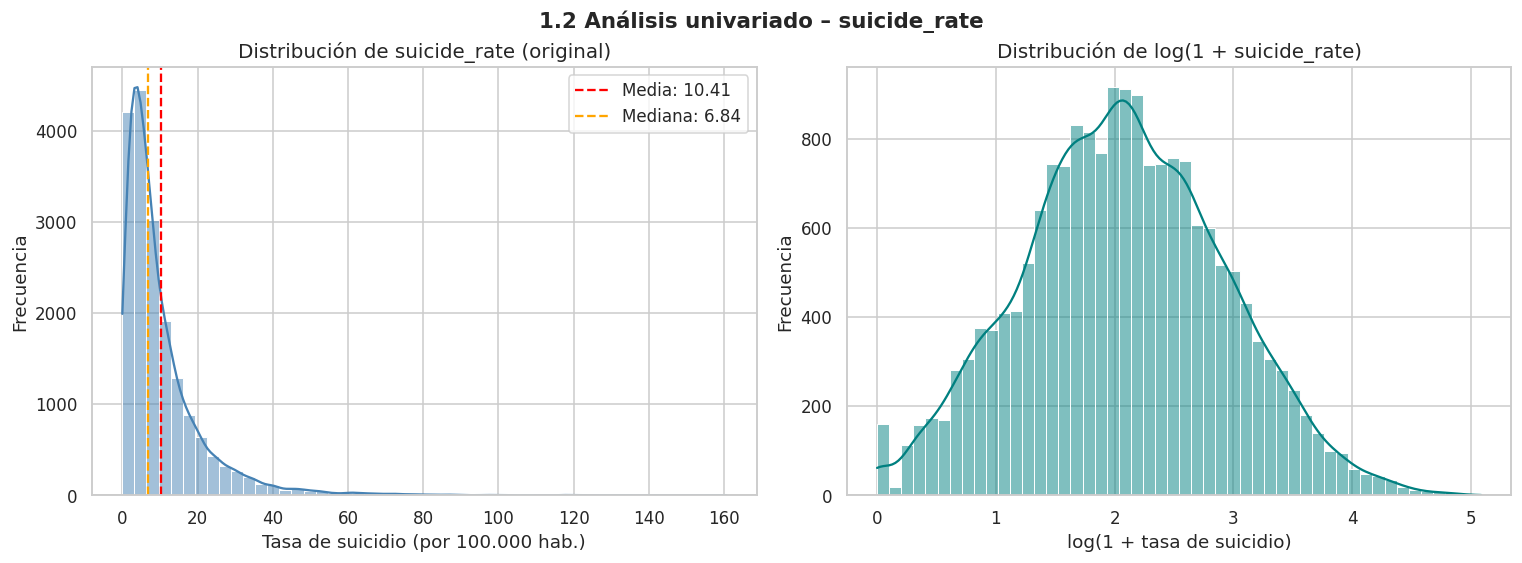

La distribución original presenta sesgo positivo (skewness=3.21).
La transformación log1p reduce el sesgo y aproxima la distribución a una normal.


In [47]:
# Histograma + curva de densidad: suicide_rate
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución original
sns.histplot(df['suicide_rate'], bins=50, kde=True, color='steelblue', ax=axes[0])
axes[0].set_title('Distribución de suicide_rate (original)', fontsize=13)
axes[0].set_xlabel('Tasa de suicidio (por 100.000 hab.)')
axes[0].set_ylabel('Frecuencia')
axes[0].axvline(df['suicide_rate'].mean(), color='red', linestyle='--', label=f"Media: {df['suicide_rate'].mean():.2f}")
axes[0].axvline(df['suicide_rate'].median(), color='orange', linestyle='--', label=f"Mediana: {df['suicide_rate'].median():.2f}")
axes[0].legend()

# Distribución con transformación log
sr_log = np.log1p(df['suicide_rate'])
sns.histplot(sr_log, bins=50, kde=True, color='teal', ax=axes[1])
axes[1].set_title('Distribución de log(1 + suicide_rate)', fontsize=13)
axes[1].set_xlabel('log(1 + tasa de suicidio)')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.suptitle('1.2 Análisis univariado – suicide_rate', y=1.02, fontsize=14, fontweight='bold')
plt.show()

print(f"La distribución original presenta sesgo positivo (skewness={df['suicide_rate'].skew():.2f}).")
print("La transformación log1p reduce el sesgo y aproxima la distribución a una normal.")

---
# 2. Análisis Multivariado
Exploración de relaciones entre múltiples variables mediante correlaciones, diagramas de dispersión, tablas cruzadas y mapas de calor.

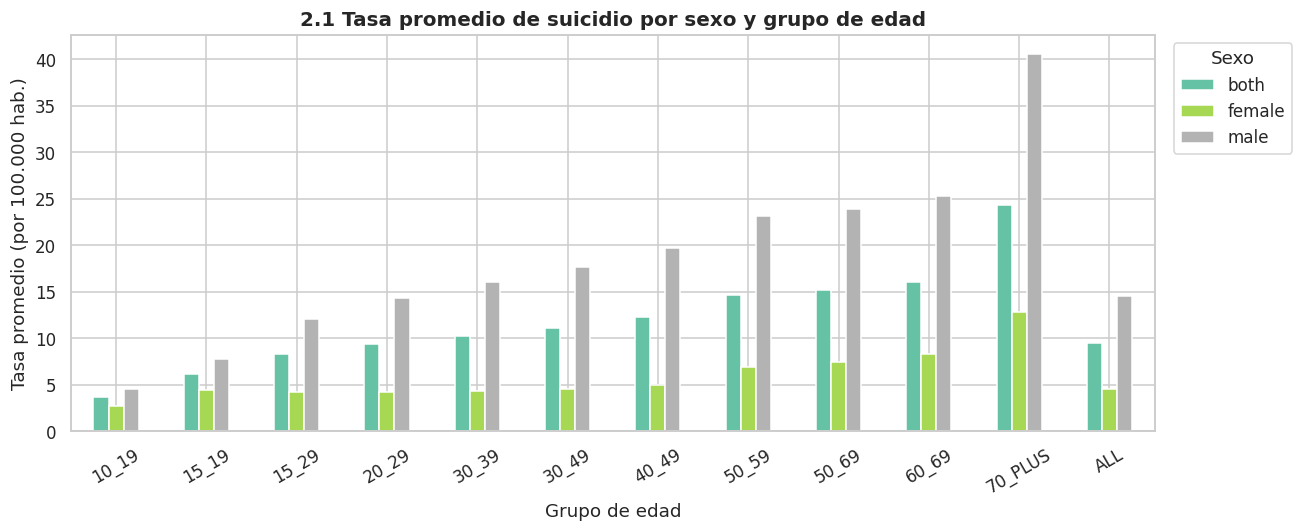

In [48]:
# @title
# ─────────────────────────────────────────────
# 2.1 Tasa de suicidio promedio por sexo y grupo de edad
# ─────────────────────────────────────────────
pivot_sex_age = df.groupby(['sex', 'age_group'])['suicide_rate'].mean().unstack()

fig, ax = plt.subplots(figsize=(12, 5))
pivot_sex_age.T.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='white')
ax.set_title('2.1 Tasa promedio de suicidio por sexo y grupo de edad', fontsize=13, fontweight='bold')
ax.set_xlabel('Grupo de edad')
ax.set_ylabel('Tasa promedio (por 100.000 hab.)')
ax.legend(title='Sexo', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

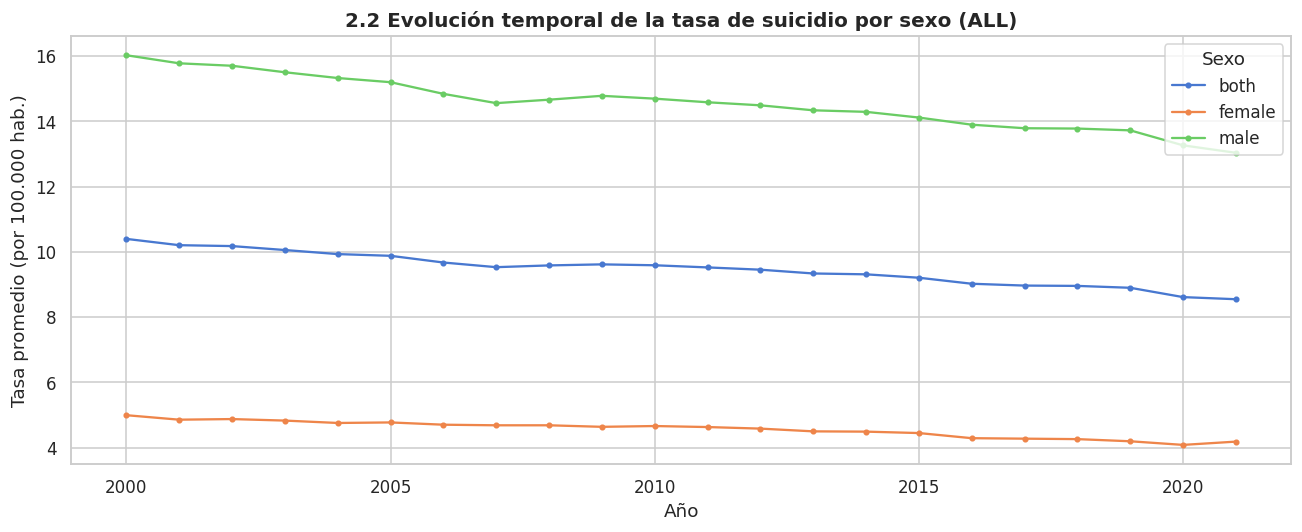

In [49]:
# ─────────────────────────────────────────────
# 2.2 Evolución temporal de la tasa de suicidio
# ─────────────────────────────────────────────
df_all = df[df['age_group'] == 'ALL'].copy()

pivot_time = df_all.groupby(['year', 'sex'])['suicide_rate'].mean().unstack()

fig, ax = plt.subplots(figsize=(12, 5))
for col in pivot_time.columns:
    ax.plot(pivot_time.index, pivot_time[col], marker='o', markersize=3, label=col)
ax.set_title('2.2 Evolución temporal de la tasa de suicidio por sexo (ALL)', fontsize=13, fontweight='bold')
ax.set_xlabel('Año')
ax.set_ylabel('Tasa promedio (por 100.000 hab.)')
ax.legend(title='Sexo')
plt.tight_layout()
plt.show()

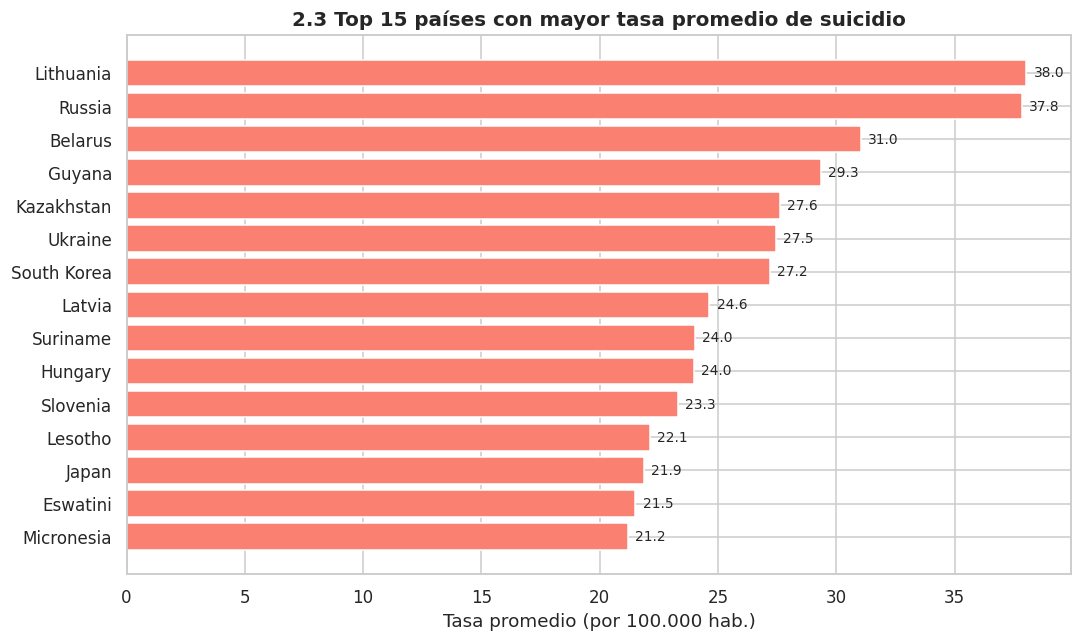

In [50]:
# @title
# ─────────────────────────────────────────────
# 2.3 Top 15 países con mayor tasa promedio de suicidio
# ─────────────────────────────────────────────
top15 = (df[df['age_group'] == 'ALL']
         .groupby('country')['suicide_rate']
         .mean()
         .sort_values(ascending=False)
         .head(15))

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top15.index[::-1], top15.values[::-1], color='salmon', edgecolor='white')
ax.set_title('2.3 Top 15 países con mayor tasa promedio de suicidio', fontsize=13, fontweight='bold')
ax.set_xlabel('Tasa promedio (por 100.000 hab.)')
for bar, val in zip(bars, top15.values[::-1]):
    ax.text(val + 0.3, bar.get_y() + bar.get_height() / 2, f'{val:.1f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

---
# 3. Relaciones entre Variables
Pairplots

In [68]:
from sklearn.preprocessing import LabelEncoder

df_corr = df.copy()

le_sex = LabelEncoder()
le_age = LabelEncoder()

df_corr['sex_enc'] = le_sex.fit_transform(df_corr['sex'])
df_corr['age_group_enc'] = le_age.fit_transform(df_corr['age_group'])

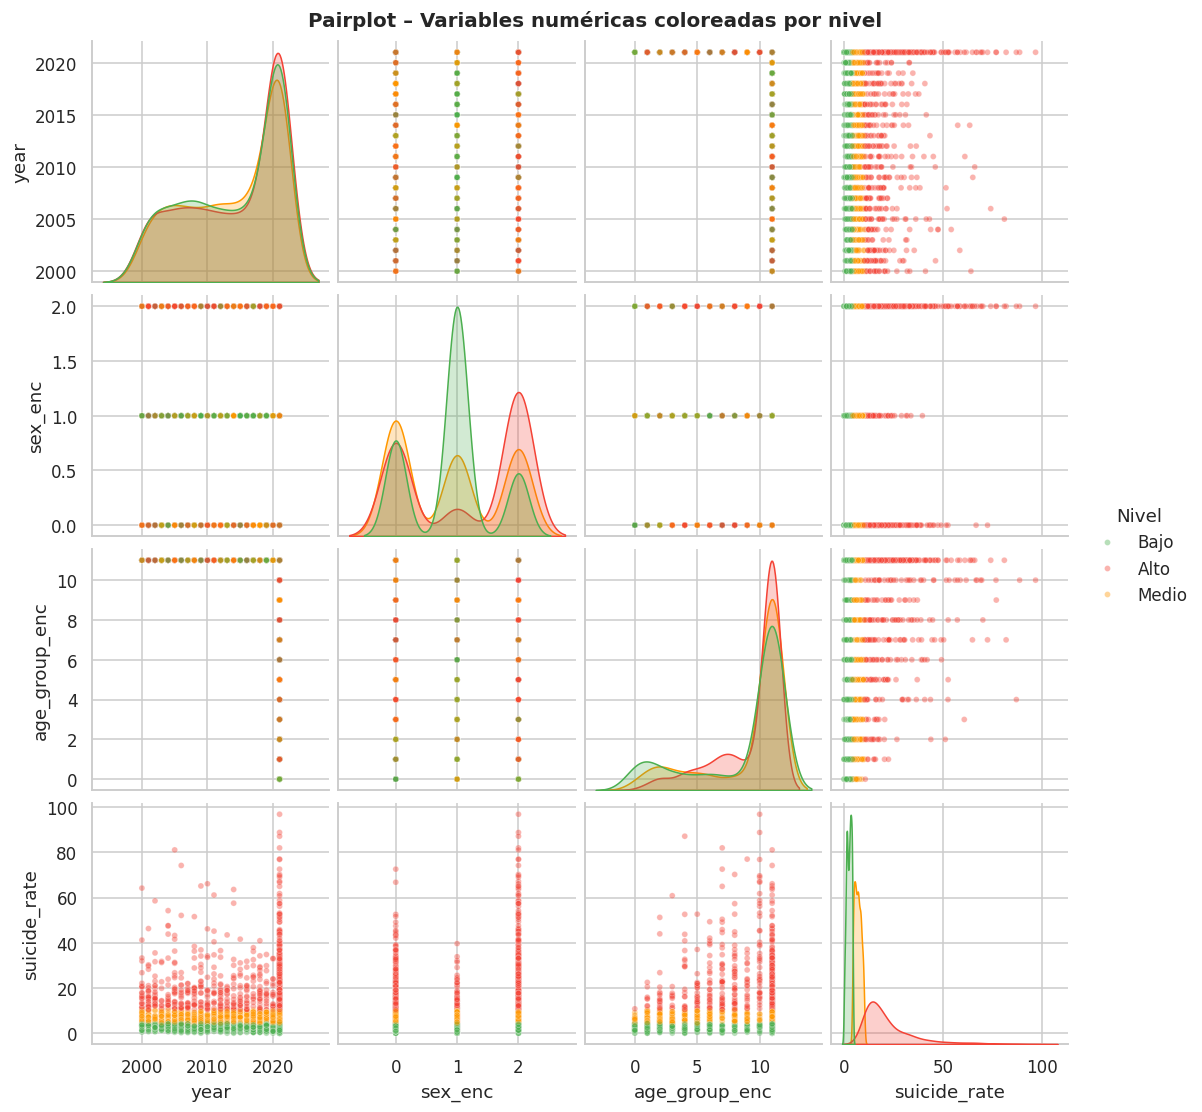

In [69]:
# Pairplot de variables numéricas clave



sample_df = df_corr[['year', 'sex_enc', 'age_group_enc', 'suicide_rate', 'level']].sample(
    n=min(2000, len(df_corr)), random_state=42
)
sample_df['Nivel'] = sample_df['level'].map({0: 'Bajo', 1: 'Medio', 2: 'Alto'})

pair = sns.pairplot(
    sample_df.drop(columns='level'),
    hue='Nivel',
    palette={'Bajo': '#4caf50', 'Medio': '#ff9800', 'Alto': '#f44336'},
    plot_kws={'alpha': 0.4, 's': 15},
    diag_kind='kde'
)
pair.fig.suptitle('Pairplot – Variables numéricas coloreadas por nivel', y=1.01, fontsize=13, fontweight='bold')
plt.show()

---
# 4. Construcción de Hipótesis Iniciales

A partir de los patrones observados, se plantean las siguientes hipótesis para ser verificadas con el dataset:

H1: ¿El sexo masculino tiene tasas más altas?
  Media hombres: 15.926  |  Media mujeres: 5.007
  Conclusión: la diferencia es significativa


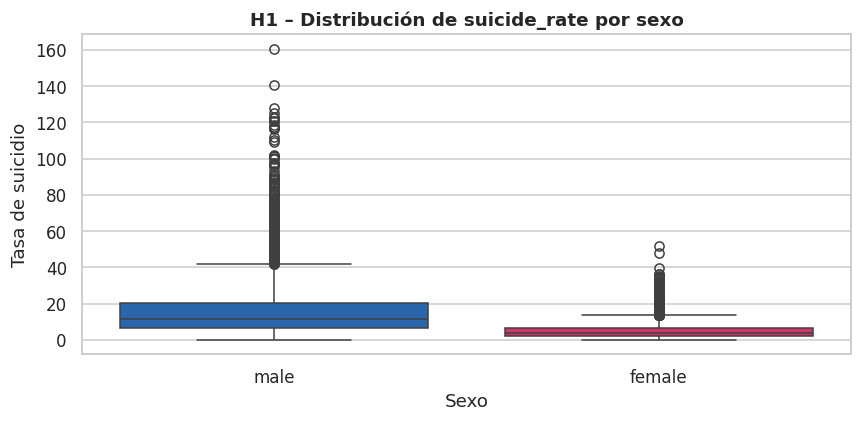

In [52]:
# @title
# ─────────────────────────────────────────────
# 4.1 H1: El sexo masculino presenta tasas de suicidio significativamente más altas que el femenino
# ─────────────────────────────────────────────
male   = df[df['sex'] == 'male']['suicide_rate'].dropna()
female = df[df['sex'] == 'female']['suicide_rate'].dropna()

t_stat, p_val = stats.mannwhitneyu(male, female, alternative='greater')
print("H1: ¿El sexo masculino tiene tasas más altas?")
print(f"  Media hombres: {male.mean():.3f}  |  Media mujeres: {female.mean():.3f}")
print(f"  Conclusión: {'la diferencia es significativa' if p_val < 0.05 else 'No hay evidencia suficiente'}")

fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=df[df['sex'].isin(['male', 'female'])],
            x='sex', y='suicide_rate', palette=['#1565c0', '#e91e63'], ax=ax)
ax.set_title('H1 – Distribución de suicide_rate por sexo', fontsize=12, fontweight='bold')
ax.set_xlabel('Sexo')
ax.set_ylabel('Tasa de suicidio')
plt.tight_layout()
plt.show()

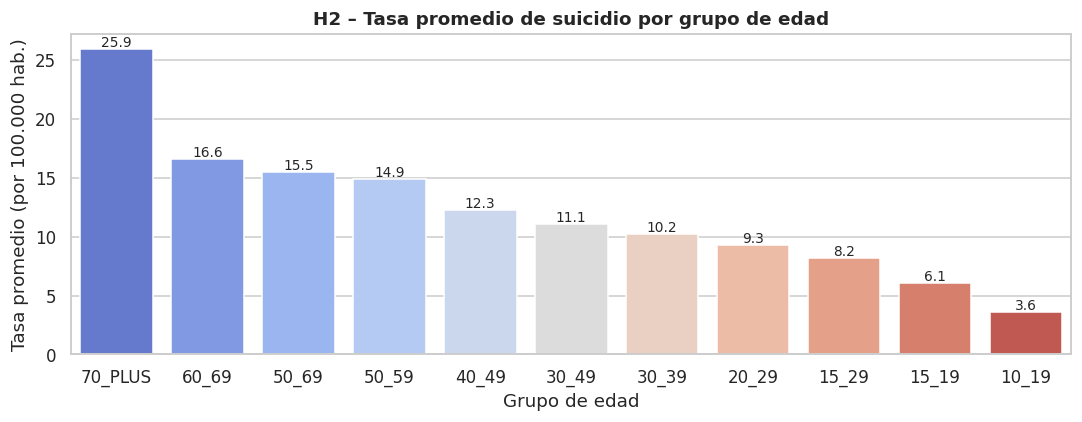

Tasa promedio por grupo de edad:
age_group
70_PLUS    25.93
60_69      16.56
50_69      15.51
50_59      14.93
40_49      12.30
30_49      11.10
30_39      10.19
20_29       9.28
15_29       8.21
15_19       6.09
10_19       3.63


In [53]:
# @title
# ─────────────────────────────────────────────
# 4.2 H2: El grupo de edad adulto mayor (70+) presenta tasas más altas que otros grupos
# ─────────────────────────────────────────────
age_mean = df[df['age_group'] != 'ALL'].groupby('age_group')['suicide_rate'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(x=age_mean.index, y=age_mean.values, palette='coolwarm', ax=ax)
ax.set_title('H2 – Tasa promedio de suicidio por grupo de edad', fontsize=12, fontweight='bold')
ax.set_xlabel('Grupo de edad')
ax.set_ylabel('Tasa promedio (por 100.000 hab.)')
for i, v in enumerate(age_mean.values):
    ax.text(i, v + 0.2, f'{v:.1f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

print("Tasa promedio por grupo de edad:")
print(age_mean.round(2).to_string())

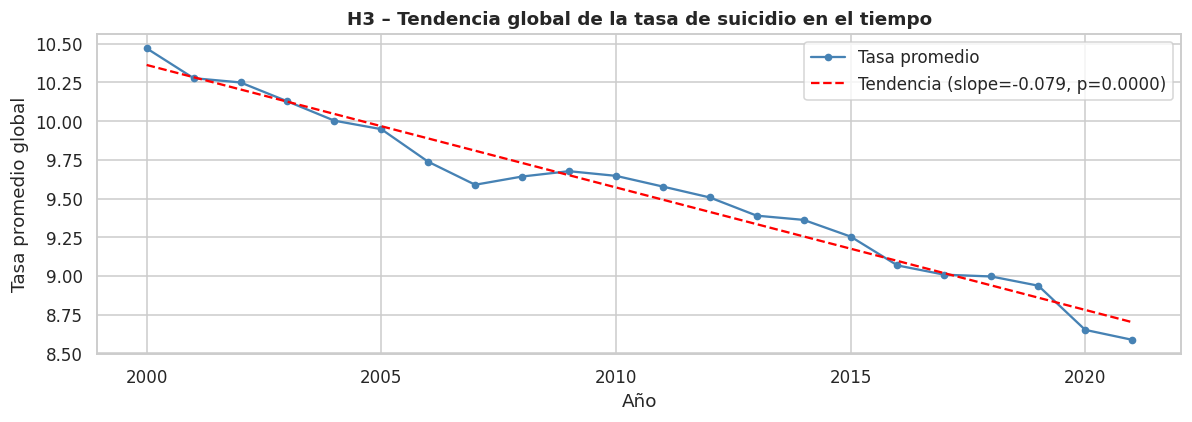

Conclusión: Hay una tendensia decreciente significativa


In [54]:
# @title
# ─────────────────────────────────────────────
# 4.3 H3: La tasa de suicidio ha disminuido globalmente con el paso de los años
# ─────────────────────────────────────────────
global_trend = df[df['age_group'] == 'ALL'].groupby('year')['suicide_rate'].mean()

# Regresión lineal simple
slope, intercept, r_val, p_trend, _ = stats.linregress(global_trend.index, global_trend.values)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(global_trend.index, global_trend.values, marker='o', markersize=4, color='steelblue', label='Tasa promedio')
ax.plot(global_trend.index, intercept + slope * global_trend.index,
        color='red', linestyle='--', label=f'Tendencia (slope={slope:.3f}, p={p_trend:.4f})')
ax.set_title('H3 – Tendencia global de la tasa de suicidio en el tiempo', fontsize=12, fontweight='bold')
ax.set_xlabel('Año')
ax.set_ylabel('Tasa promedio global')
ax.legend()
plt.tight_layout()
plt.show()

print("Conclusión:", "Hay una tendensia decreciente significativa" if slope < 0 and p_trend < 0.05 else "No hay tendencia clara")

### Resumen de hipótesis planteadas

| # | Hipótesis | Variable(s) involucrada(s) |
|---|-----------|----------------------------|
| H1 | El sexo masculino presenta tasas de suicidio significativamente más altas que el femenino | `sex`, `suicide_rate` |
| H2 | Los grupos de mayor edad (50+) tienen tasas de suicidio más altas que los jóvenes | `age_group`, `suicide_rate` |
| H3 | La tasa global de suicidio ha disminuido progresivamente a lo largo de los años | `year`, `suicide_rate` |

---
# 5. Visualizaciones Clave
Histogramas, boxplots, gráficas de barras, diagramas de dispersión, mapas de calor y series de tiempo.

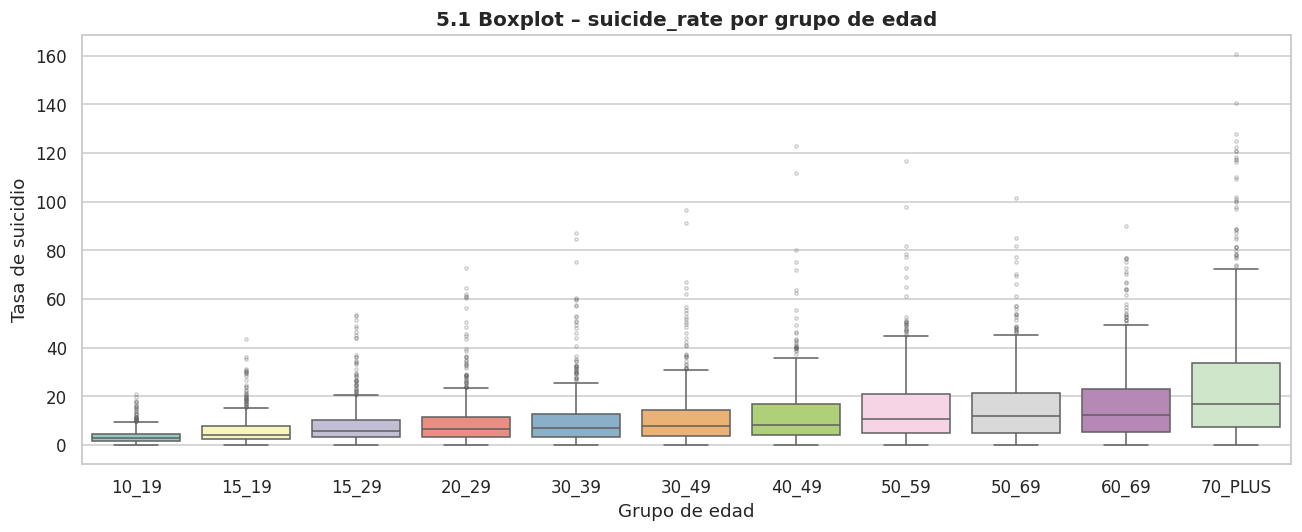

In [55]:
# @title
# ─────────────────────────────────────────────
# 5.1 Boxplots – distribución y outliers por grupo de edad
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
order_age = df[df['age_group'] != 'ALL']['age_group'].value_counts().index.tolist()
sns.boxplot(
    data=df[df['age_group'] != 'ALL'],
    x='age_group', y='suicide_rate',
    order=sorted(order_age),
    palette='Set3', ax=ax, flierprops=dict(marker='o', markersize=2, alpha=0.3)
)
ax.set_title('5.1 Boxplot – suicide_rate por grupo de edad', fontsize=13, fontweight='bold')
ax.set_xlabel('Grupo de edad')
ax.set_ylabel('Tasa de suicidio')
plt.tight_layout()
plt.show()

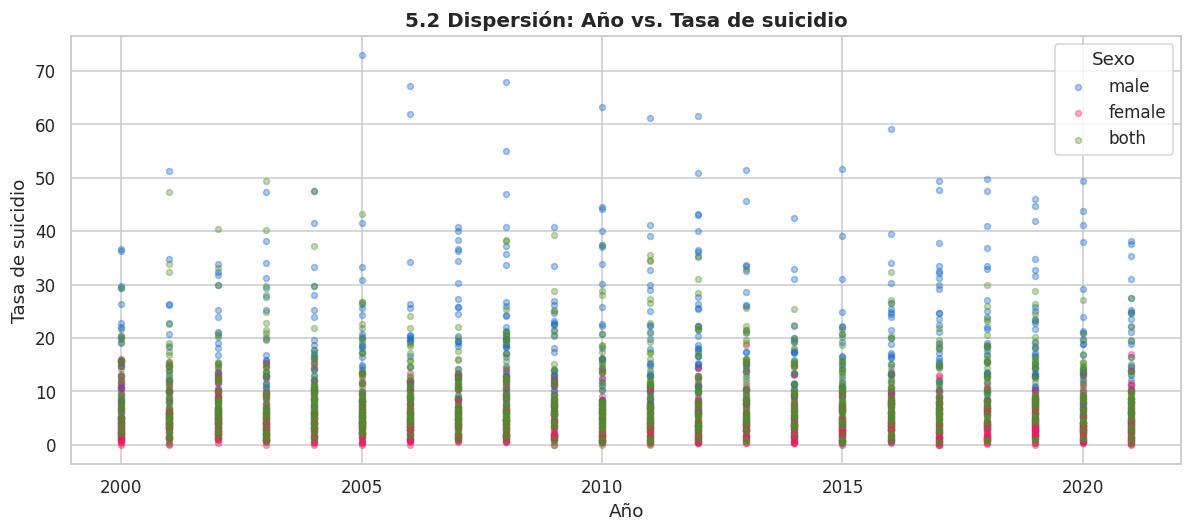

In [56]:
# @title
# ─────────────────────────────────────────────
# 5.2 Diagrama de dispersión: año vs. tasa de suicidio coloreado por sexo
# ─────────────────────────────────────────────
sample_scatter = df[df['age_group'] == 'ALL'].sample(n=min(3000, len(df)), random_state=1)

fig, ax = plt.subplots(figsize=(11, 5))
for sex, color in zip(['male', 'female', 'both'], ['#1565c0', '#e91e63', '#558b2f']):
    sub = sample_scatter[sample_scatter['sex'] == sex]
    ax.scatter(sub['year'], sub['suicide_rate'], alpha=0.35, s=15, color=color, label=sex)
ax.set_title('5.2 Dispersión: Año vs. Tasa de suicidio', fontsize=13, fontweight='bold')
ax.set_xlabel('Año')
ax.set_ylabel('Tasa de suicidio')
ax.legend(title='Sexo')
plt.tight_layout()
plt.show()

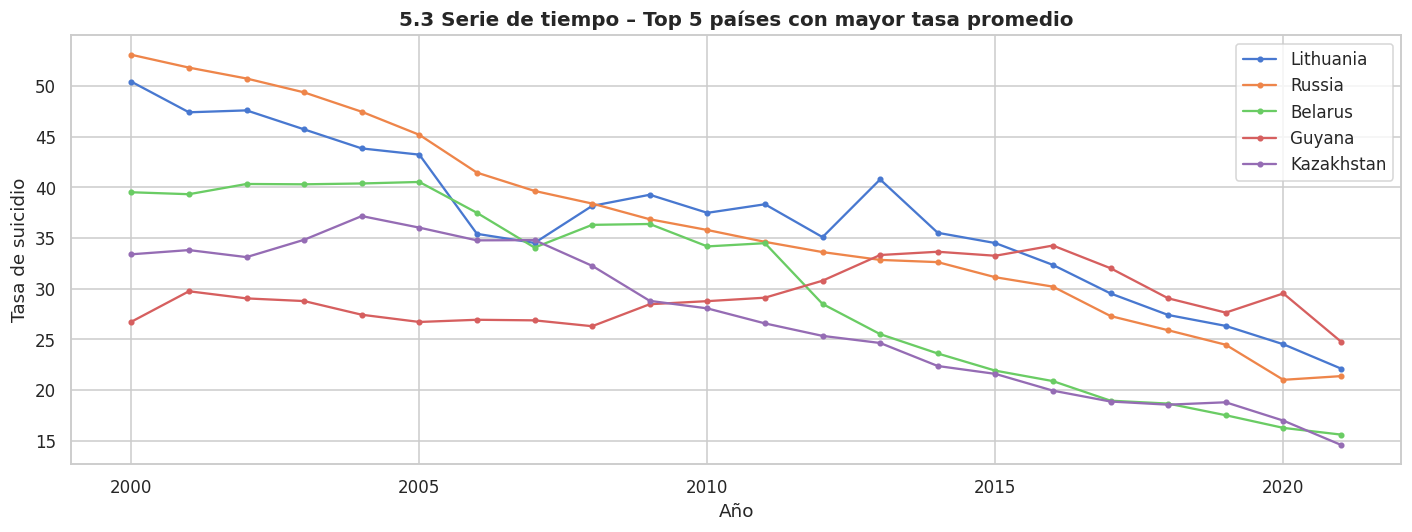

In [57]:
# @title

# ─────────────────────────────────────────────
# 5.3 Serie de tiempo: top 5 países con mayor tasa
# ─────────────────────────────────────────────
top5_countries = (df[df['age_group'] == 'ALL']
                  .groupby('country')['suicide_rate'].mean()
                  .nlargest(5).index.tolist())

df_top5 = df[(df['country'].isin(top5_countries)) &
             (df['age_group'] == 'ALL') &
             (df['sex'] == 'both')]

fig, ax = plt.subplots(figsize=(13, 5))
for country in top5_countries:
    sub = df_top5[df_top5['country'] == country].sort_values('year')
    ax.plot(sub['year'], sub['suicide_rate'], marker='o', markersize=3, label=country)
ax.set_title('5.3 Serie de tiempo – Top 5 países con mayor tasa promedio', fontsize=13, fontweight='bold')
ax.set_xlabel('Año')
ax.set_ylabel('Tasa de suicidio')
ax.legend()
plt.tight_layout()
plt.show()

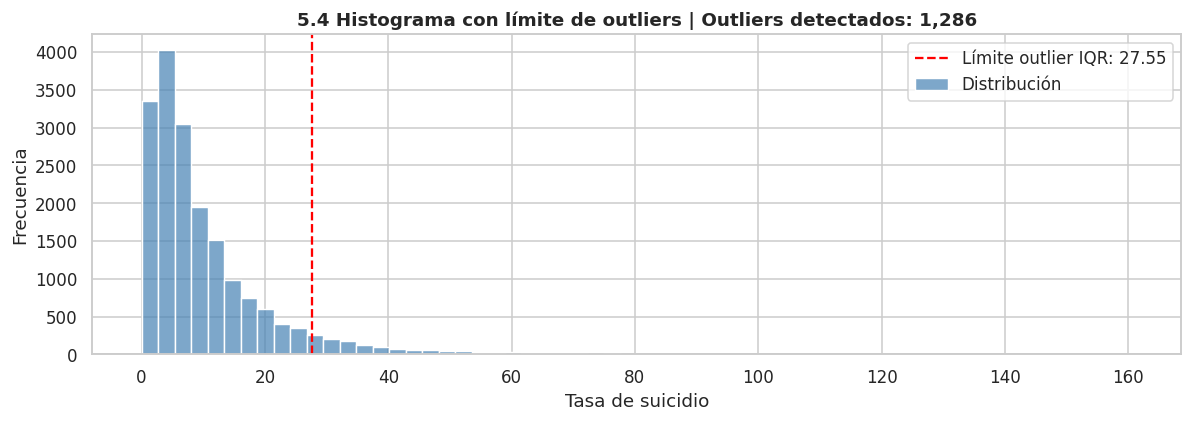

Total de outliers (>27.55): 1,286 registros (7.02%)


In [58]:
# @title
# ─────────────────────────────────────────────
# 5.4 Histograma con outliers marcados
# ─────────────────────────────────────────────
q3_sr = df['suicide_rate'].quantile(0.75)
iqr_sr = q3_sr - df['suicide_rate'].quantile(0.25)
upper_fence = q3_sr + 1.5 * iqr_sr
outliers = df[df['suicide_rate'] > upper_fence]

fig, ax = plt.subplots(figsize=(11, 4))
sns.histplot(df['suicide_rate'], bins=60, color='steelblue', alpha=0.7, ax=ax, label='Distribución')
ax.axvline(upper_fence, color='red', linestyle='--', linewidth=1.5, label=f'Límite outlier IQR: {upper_fence:.2f}')
ax.set_title(f'5.4 Histograma con límite de outliers | Outliers detectados: {len(outliers):,}', fontsize=12, fontweight='bold')
ax.set_xlabel('Tasa de suicidio')
ax.set_ylabel('Frecuencia')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Total de outliers (>{upper_fence:.2f}): {len(outliers):,} registros ({len(outliers)/len(df)*100:.2f}%)")

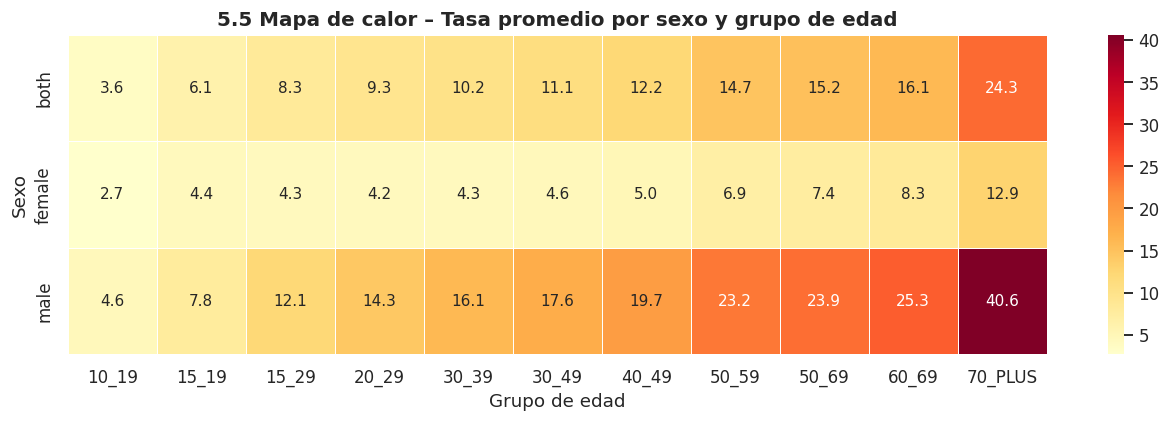

In [59]:
# @title
# ─────────────────────────────────────────────
# 5.5 Mapa de calor: interacción sexo x age_group
# ─────────────────────────────────────────────
pivot_sex_age2 = df[df['age_group'] != 'ALL'].pivot_table(
    values='suicide_rate', index='sex', columns='age_group', aggfunc='mean'
)

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(pivot_sex_age2, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, annot_kws={'size': 10})
ax.set_title('5.5 Mapa de calor – Tasa promedio por sexo y grupo de edad', fontsize=13, fontweight='bold')
ax.set_xlabel('Grupo de edad')
ax.set_ylabel('Sexo')
plt.tight_layout()
plt.show()

---
# 6. Insights Principales

Resumen de patrones relevantes, problemas de calidad y líneas de análisis futuras.

In [60]:
# @title
#Resumen de insights

mean_male   = df[df['sex'] == 'male']['suicide_rate'].mean()
mean_female = df[df['sex'] == 'female']['suicide_rate'].mean()
ratio_sex   = mean_male / mean_female

age_means = df[df['age_group'] != 'ALL'].groupby('age_group')['suicide_rate'].mean()
top_age   = age_means.idxmax()

global_first = df[df['age_group'] == 'ALL'].groupby('year')['suicide_rate'].mean()
trend_dir = 'descendente' if global_first.iloc[-1] < global_first.iloc[0] else 'ascendente'

top_country = (df[df['age_group'] == 'ALL']
               .groupby('country')['suicide_rate'].mean().idxmax())

n_outliers = len(df[df['suicide_rate'] > upper_fence])

print("" + "="*65)
print("  RESUMEN DE INSIGHTS PRINCIPALES – EDA Suicidios Dataset")
print("="*65)
print(f"""
1. BRECHA DE GÉNERO
   Los hombres presentan una tasa promedio {ratio_sex:.1f}x mayor que las mujeres ({mean_male:.2f} vs {mean_female:.2f} por 100.000 hab.).
   Esta diferencia es estadísticamente significativa (Mann-Whitney, p<0.05).

2. GRUPO DE EDAD CRÍTICO
   El grupo de edad '{top_age}' concentra la tasa promedio más alta ({age_means[top_age]:.2f}), sugiriendo que la edad avanzada es
   un factor de riesgo diferencial.

3. TENDENCIA TEMPORAL {trend_dir.upper()}
   La tasa global muestra una tendencia {trend_dir} desde el año
   {int(global_first.index[0])} hasta {int(global_first.index[-1])}.
   ({global_first.iloc[0]:.2f} → {global_first.iloc[-1]:.2f} por 100.000 hab.)

4. HETEROGENEIDAD GEOGRÁFICA
   El país con mayor tasa promedio es {top_country}. La varianza entre países supera a la varianza intra-país,
   indicando que el contexto nacional es un predictor relevante.

5. SESGO POSITIVO Y OUTLIERS
   La distribución de suicide_rate tiene sesgo positivo pronunciado (skewness={df['suicide_rate'].skew():.2f}).
   Se detectaron {n_outliers:,} valores atípicos (>{upper_fence:.1f}),
   lo que podría requerir transformación log antes de modelar.
""")

print("─"*65)
print("PROBLEMAS DE CALIDAD DETECTADOS")
print("─"*65)
n_nulls = df.isnull().sum().sum()
print(f"-Valores nulos tras limpieza: {n_nulls}")
print(f"-Registros con suicide_rate = 0: {(df['suicide_rate'] == 0).sum()}")
print(f"-Registros duplicados: {df.duplicated().sum()}")

print("\n" + "─"*65)
print("LÍNEAS DE ANÁLISIS FUTURAS")
print("─"*65)
print("1. Incorporar variables socioeconómicas (PIB, desempleo, IDH) para enriquecer el modelo clasificador.")
print("2. Aplicar transformación log1p a suicide_rate antes del modelado.")
print("3. Modelar la brecha de género como variable de interacción.")
print("4. Analizar cambios para eventos globales (crisis, pandemias).")

  RESUMEN DE INSIGHTS PRINCIPALES – EDA Suicidios Dataset

1. BRECHA DE GÉNERO
   Los hombres presentan una tasa promedio 3.2x mayor que las mujeres (15.93 vs 5.01 por 100.000 hab.).
   Esta diferencia es estadísticamente significativa (Mann-Whitney, p<0.05).

2. GRUPO DE EDAD CRÍTICO
   El grupo de edad '70_PLUS' concentra la tasa promedio más alta (25.93), sugiriendo que la edad avanzada es
   un factor de riesgo diferencial.

3. TENDENCIA TEMPORAL DESCENDENTE
   La tasa global muestra una tendencia descendente desde el año
   2000 hasta 2021.
   (10.47 → 8.59 por 100.000 hab.)

4. HETEROGENEIDAD GEOGRÁFICA
   El país con mayor tasa promedio es Lithuania. La varianza entre países supera a la varianza intra-país,
   indicando que el contexto nacional es un predictor relevante.

5. SESGO POSITIVO Y OUTLIERS
   La distribución de suicide_rate tiene sesgo positivo pronunciado (skewness=3.21).
   Se detectaron 1,286 valores atípicos (>27.6),
   lo que podría requerir transformación log an

# FASE 3 Preprocesamiento y reducción

## 1 Codificación de variables categóricas

In [2]:
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA

df_model = df.copy()

# Label Encoding para sex y age_group
le_sex = LabelEncoder()
le_age = LabelEncoder()

df_model['sex_enc']       = le_sex.fit_transform(df_model['sex'])
df_model['age_group_enc'] = le_age.fit_transform(df_model['age_group'])

print("Mapeo sex:", dict(zip(le_sex.classes_, le_sex.transform(le_sex.classes_))))
print("Mapeo age_group:", dict(zip(le_age.classes_, le_age.transform(le_age.classes_))))

Mapeo sex: {'both': np.int64(0), 'female': np.int64(1), 'male': np.int64(2)}
Mapeo age_group: {'10_19': np.int64(0), '15_19': np.int64(1), '15_29': np.int64(2), '20_29': np.int64(3), '30_39': np.int64(4), '30_49': np.int64(5), '40_49': np.int64(6), '50_59': np.int64(7), '50_69': np.int64(8), '60_69': np.int64(9), '70_PLUS': np.int64(10), 'ALL': np.int64(11)}


## 2 Escalado de variables

In [3]:
# Transformación log1p a suicide_rate (corrige el sesgo pronunciado detectado en el EDA)
df_model['suicide_rate_log'] = np.log1p(df_model['suicide_rate'])

# StandardScaler sobre year y suicide_rate_log
scaler = StandardScaler()
df_model[['year_sc', 'suicide_rate_sc']] = scaler.fit_transform(
    df_model[['year', 'suicide_rate_log']]
)

print(df_model[['year_sc', 'suicide_rate_sc']].describe().round(3))

         year_sc  suicide_rate_sc
count  18315.000        18315.000
mean      -0.000           -0.000
std        1.000            1.000
min       -1.954           -2.426
25%       -0.837           -0.680
50%        0.279           -0.011
75%        0.977            0.676
max        0.977            3.537


## 3 Reducción de dimensionalidad

Varianza explicada — PC1: 83.6%  |  PC2: 7.5%
Varianza acumulada (2 PC): 91.1%


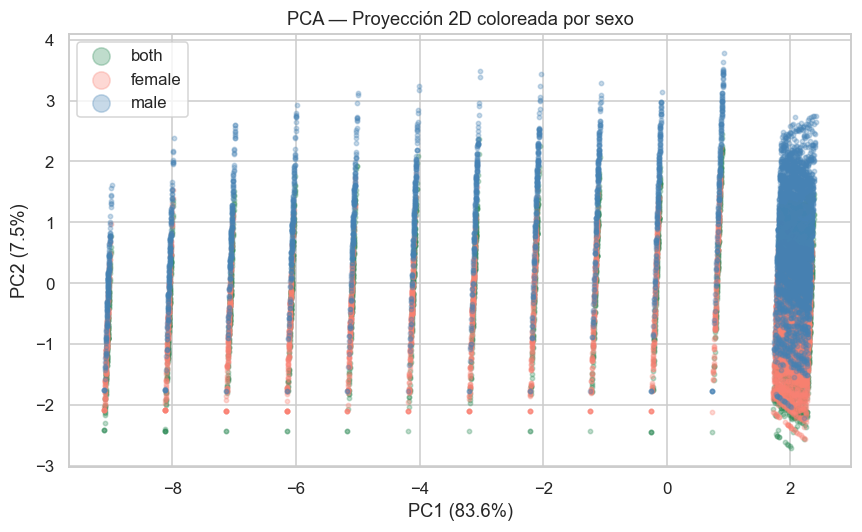

In [4]:
features = ['year_sc', 'suicide_rate_sc', 'sex_enc', 'age_group_enc']
X = df_model[features].values

pca = PCA(n_components=2)
componentes = pca.fit_transform(X)

print(f"Varianza explicada — PC1: {pca.explained_variance_ratio_[0]*100:.1f}%  |  PC2: {pca.explained_variance_ratio_[1]*100:.1f}%")
print(f"Varianza acumulada (2 PC): {sum(pca.explained_variance_ratio_)*100:.1f}%")

# Visualización
fig, ax = plt.subplots(figsize=(8, 5))
palette = {'male': 'steelblue', 'female': 'salmon', 'both': 'seagreen'}
for sex_val, grp_idx in df_model.groupby('sex').groups.items():
    ax.scatter(componentes[grp_idx, 0], componentes[grp_idx, 1],
               label=sex_val, alpha=0.3, s=8, color=palette[sex_val])

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('PCA — Proyección 2D coloreada por sexo')
ax.legend(markerscale=4)
plt.tight_layout()
plt.show()